cuda


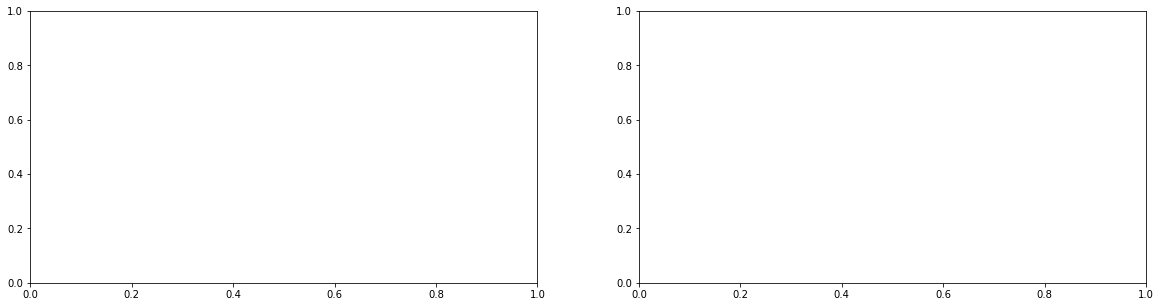

In [1]:
import os
import sys
import time
import copy
sys.path.append('../SLM/')

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

import numpy as np
import json
import math
import random

import fnmatch
import re
from itertools import product, groupby

import matplotlib
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

from tokenizers import Tokenizer

import models, init, train, measures
import importlib
# Reload the modules
importlib.reload( models)

device = 'cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu'
print(device)

def collect(path, prefix, *keys):

    all_entries = os.listdir(path)
    matching_entries = []
    for entry in all_entries:

        if fnmatch.fnmatch(entry, prefix+'*'):

            check_keys = 1
            for key in keys:
                check_keys *= fnmatch.fnmatch(entry, '*'+key+'*')
            if check_keys:
                ending = re.sub(prefix, '', entry)
#                 params = re.findall(r'_P(\d+)', ending)
#                 assert params, f'{entry}: trainsize p not found!'
                array = re.findall(r'_(\d+)', ending)
                matching_entries.append({
                    'ending': ending,
#                     'P': int(params[0]),
                    'seed': int(array[0])
                })
#     matching_entries.sort(key=lambda x: [x.get('P'), x.get('exp')])
    return matching_entries


def find_all(path, prefix, what, *keys):
    
    all_entries = os.listdir(path)
    params = []
    for entry in all_entries:

        if fnmatch.fnmatch(entry, prefix+'*'):

            check_keys = 1
            for key in keys:
                check_keys *= fnmatch.fnmatch(entry, '*'+key+'*')
            if check_keys:
                ending = re.sub(prefix, '', entry)
                param = re.findall(what+r'(\d+)', ending)
                param = int(param[0])
                if param not in params:
                    params.append(param)
    params.sort()
    return params


def find_lowest(path, prefix, what, *keys):
    
    all_entries = os.listdir(path)
    params = []
    for entry in all_entries:

        if fnmatch.fnmatch(entry, prefix+'*'):

            check_keys = 1
            for key in keys:
                check_keys *= fnmatch.fnmatch(entry, '*'+key+'*')
            if check_keys:
                ending = re.sub(prefix, '', entry)
                param = re.findall(what+r'(\d+)', ending)
                param = int(param[0])
                if param not in params:
                    params.append(param)
    params.sort()
    return params[0]


def get_loss(path, prefix):

    loss_list = []

    p_list = find_all(path, prefix, 'P')
    print('training set sizes: ', p_list)

    for  p in p_list:

        bs = find_lowest(path, prefix, 'bs', f'P{p}_')
        print(f'P={p}, batch size={bs}')
        collection = collect( path, prefix, f'P{p}_', f'bs{bs}_')
        loss = []

        for entry in collection:
            try:
                results = torch.load(path+prefix+entry['ending'])
                print(p, results['best']['loss'])
                loss.append(results['best']['loss'])

            except:
                print(path+prefix+entry['ending']+f' not found.')


        print(f'{len(loss)} exps. , mean loss {torch.tensor(loss).mean()}')
        loss_list.append(torch.tensor(loss))
    return loss_list


fig, ax = plt.subplots(1, 2, figsize=(20,5.0))

768 1 3e-4 2.0 tensor(4.2280) tensor(0.0088)
768 1 3e-4 4.0 tensor(4.2901) tensor(0.0179)
768 1 3e-4 8.0 tensor(4.2930) tensor(0.0410)
768 1 1e-3 2.0 tensor(4.3275) tensor(0.0305)
768 1 1e-3 4.0 tensor(4.4152) tensor(0.0679)
768 1 1e-3 8.0 tensor(4.3611) tensor(0.0313)
768 2 3e-4 2.0 tensor(4.0281) tensor(0.0231)
768 2 3e-4 4.0 tensor(3.9706) tensor(0.0229)
768 2 3e-4 8.0 tensor(4.0069) tensor(0.0271)
768 2 1e-3 2.0 tensor(4.0412) tensor(0.0112)
768 2 1e-3 4.0 tensor(3.9851) tensor(0.0289)
768 2 1e-3 8.0 tensor(4.1069) tensor(0.0424)
torch.Size([8130])
tensor(5.7761)


Text(0.5, 0, 'training step (batch size $=2$)')

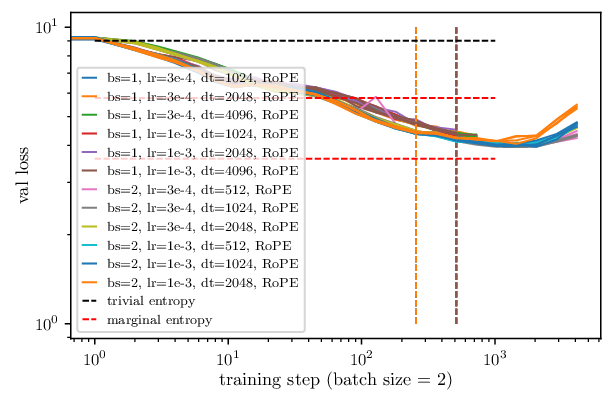

In [6]:
matplotlib.use("pgf")
matplotlib.rcParams.update({
    "pgf.texsystem": "pdflatex",
    'font.family': 'serif',
    'text.usetex': True,
    'pgf.rcfonts': False,
    'font.size': 10,
    'lines.markersize': 4,
    'lines.linewidth': 1.0,
})
# fig, ax = plt.subplots(1, 1, figsize=(1*3.8, 1*2.4), dpi=120)
fig, ax = plt.subplots(1, 1, figsize=(1*5.7, 1*3.6), dpi=120)
custom_lines = []
custom_labels = []


vocab_size = 8192
split = 'train'
i = -1

T = 128
P = 65536
path = f'tinystories/trained/T{T}_rope/P{P}/'

depth = 12
de = 768
nh = 12

bs = 1
for lr in ['3e-4', '1e-3']:
    for dt in [1024, 2048, 4096]:
        dt_ep = dt//(P/(bs*T))
        i += 1
        prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
        collection = collect( path, prefix)
        mean_loss = []
        for entry in collection:

            results = torch.load(path+prefix+entry['ending'])
            dynamics = results['dynamics']
            ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
            mean_loss.append(results['best']['loss'])
        #     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
        print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
        ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
        custom_lines.append(Line2D([0], [0], color=f'C{i}'))
        custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}, RoPE')

bs = 2
for lr in ['3e-4', '1e-3']:
    for dt in [512, 1024, 2048]:
        dt_ep = dt//(P/(bs*T))
        i += 1
        prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
        collection = collect( path, prefix)
        mean_loss = []
        for entry in collection:

            results = torch.load(path+prefix+entry['ending'])
            dynamics = results['dynamics']
            ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
            mean_loss.append(results['best']['loss'])
        #     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
        print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
        ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
        custom_lines.append(Line2D([0], [0], color=f'C{i}'))
        custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}, RoPE')


ax.plot([1e0,1e3],[math.log(8192),math.log(8192)], 'k--')
custom_lines.append(Line2D([0], [0], color='k', linestyle='dashed'))
custom_labels.append(fr'trivial entropy')

marginal = np.load("../SLM/datasets/tinystories/"+f"tinystories.BPE{vocab_size}.{split}_marginal.npy")
marginal = torch.from_numpy(marginal)
marg_ent = torch.masked_select(marginal, (marginal>0))
print(marg_ent.size())
marg_ent = -(marg_ent*marg_ent.log()).sum()
print(marg_ent)
ax.plot([1e0,1e3],[marg_ent.cpu(),marg_ent.cpu()], 'r--')
custom_lines.append(Line2D([0], [0], color='r', linestyle='dashed'))
custom_labels.append(fr'marginal entropy')


ax.plot([1e0,1e3],[3.60,3.60], 'r--')


ax.legend(custom_lines, custom_labels, fontsize=8, handlelength=1)
# ax.set_xlim(1,16)
ax.set_xscale('log')
# ax.set_ylim(1.,5.)
ax.set_yscale('log')

ax.set_ylabel(fr'val loss', fontsize=11)
ax.set_xlabel(fr'training step (batch size $={bs}$)', fontsize=11)

768 1 3e-4 2.0 tensor(3.5050) tensor(0.0129)
768 1 3e-4 4.0 tensor(3.5456) tensor(0.0119)
768 1 3e-4 8.0 tensor(3.5543) tensor(0.0254)
768 1 1e-3 2.0 tensor(nan) tensor(nan)
768 1 1e-3 4.0 tensor(nan) tensor(nan)
768 1 1e-3 8.0 tensor(nan) tensor(nan)
768 2 3e-4 2.0 tensor(3.2347) tensor(0.0125)
768 2 3e-4 4.0 tensor(3.1451) tensor(0.0074)
768 2 3e-4 8.0 tensor(3.2403) tensor(0.0176)
768 2 1e-3 2.0 tensor(3.1968) tensor(0.0294)
768 2 1e-3 4.0 tensor(3.1862) tensor(0.0039)
768 2 1e-3 8.0 tensor(3.3693) tensor(0.0076)
768 4 3e-4 2.0 tensor(3.2749) tensor(0.0141)
768 4 3e-4 4.0 tensor(3.2042) tensor(0.0171)
768 4 3e-4 8.0 tensor(3.2391) tensor(0.0240)
768 4 1e-3 2.0 tensor(nan) tensor(nan)
768 4 1e-3 4.0 tensor(3.1459) tensor(0.0251)
768 4 1e-3 8.0 tensor(nan) tensor(nan)
768 4 1e-3 4.0 tensor(3.6964) tensor(0.0257)
torch.Size([8130])
tensor(5.7761)


Text(0.5, 0, 'training step (batch size $=4$)')

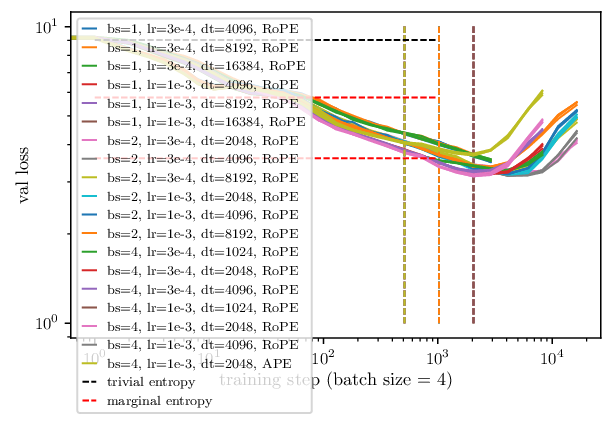

In [3]:
matplotlib.use("pgf")
matplotlib.rcParams.update({
    "pgf.texsystem": "pdflatex",
    'font.family': 'serif',
    'text.usetex': True,
    'pgf.rcfonts': False,
    'font.size': 10,
    'lines.markersize': 4,
    'lines.linewidth': 1.0,
})
# fig, ax = plt.subplots(1, 1, figsize=(1*3.8, 1*2.4), dpi=120)
fig, ax = plt.subplots(1, 1, figsize=(1*5.7, 1*3.6), dpi=120)
custom_lines = []
custom_labels = []


vocab_size = 8192
split = 'train'
i = -1

T = 128
P = 262144
path = f'tinystories/trained/T{T}_rope/P{P}/'

depth = 12
de = 768
nh = 12

bs = 1
for lr in ['3e-4', '1e-3']:
    for dt in [4096, 8192, 16384]:
        dt_ep = dt//(P/(bs*T))
        i += 1
        prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
        collection = collect( path, prefix)
        mean_loss = []
        for entry in collection:

            results = torch.load(path+prefix+entry['ending'])
            dynamics = results['dynamics']
            ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
            mean_loss.append(results['best']['loss'])
        #     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
        print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
        ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
        custom_lines.append(Line2D([0], [0], color=f'C{i}'))
        custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}, RoPE')

bs = 2
for lr in ['3e-4', '1e-3']:
    for dt in [2048, 4096, 8192]:
        dt_ep = dt//(P/(bs*T))
        i += 1
        prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
        collection = collect( path, prefix)
        mean_loss = []
        for entry in collection:

            results = torch.load(path+prefix+entry['ending'])
            dynamics = results['dynamics']
            ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
            mean_loss.append(results['best']['loss'])
        #     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
        print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
        ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
        custom_lines.append(Line2D([0], [0], color=f'C{i}'))
        custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}, RoPE')

bs = 4
for lr in ['3e-4', '1e-3']:
    for dt in [1024, 2048, 4096]:
        dt_ep = dt//(P/(bs*T))
        i += 1
        prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
        collection = collect( path, prefix)
        mean_loss = []
        for entry in collection:

            results = torch.load(path+prefix+entry['ending'])
            dynamics = results['dynamics']
            ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
            mean_loss.append(results['best']['loss'])
        #     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
        print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
        ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
        custom_lines.append(Line2D([0], [0], color=f'C{i}'))
        custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}, RoPE')

path = f'tinystories/trained/T{T}/P{P}/'

depth = 12
de = 768
nh = 12

bs = 4
lr = '1e-3'
dt = 2048
dt_ep = dt//(P/(bs*T))
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
mean_loss = []
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    mean_loss.append(results['best']['loss'])
#     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}, APE')


ax.plot([1e0,1e3],[math.log(8192),math.log(8192)], 'k--')
custom_lines.append(Line2D([0], [0], color='k', linestyle='dashed'))
custom_labels.append(fr'trivial entropy')

marginal = np.load("../SLM/datasets/tinystories/"+f"tinystories.BPE{vocab_size}.{split}_marginal.npy")
marginal = torch.from_numpy(marginal)
marg_ent = torch.masked_select(marginal, (marginal>0))
print(marg_ent.size())
marg_ent = -(marg_ent*marg_ent.log()).sum()
print(marg_ent)
ax.plot([1e0,1e3],[marg_ent.cpu(),marg_ent.cpu()], 'r--')
custom_lines.append(Line2D([0], [0], color='r', linestyle='dashed'))
custom_labels.append(fr'marginal entropy')


ax.plot([1e0,1e3],[3.60,3.60], 'r--')


ax.legend(custom_lines, custom_labels, fontsize=8, handlelength=1)
# ax.set_xlim(1,16)
ax.set_xscale('log')
# ax.set_ylim(1.,5.)
ax.set_yscale('log')

ax.set_ylabel(fr'val loss', fontsize=11)
ax.set_xlabel(fr'training step (batch size $={bs}$)', fontsize=11)

# $P=2^{20}$

768 2 3e-4 2.0 tensor(2.6072) tensor(0.0147)
768 2 3e-4 4.0 tensor(2.5688) tensor(0.0070)
768 2 3e-4 8.0 tensor(2.6882) tensor(0.0249)
768 2 1e-3 2.0 tensor(2.6211) tensor(0.0196)
768 2 1e-3 4.0 tensor(2.6580) tensor(0.0180)
768 2 1e-3 8.0 tensor(2.7115) tensor(0.0070)
768 4 1e-4 2.0 tensor(2.8273) tensor(0.0173)
768 4 1e-4 4.0 tensor(2.7365) tensor(0.0161)
768 4 1e-4 8.0 tensor(2.7420) tensor(0.0148)
768 4 3e-4 2.0 tensor(2.6498) tensor(0.0163)
768 4 3e-4 4.0 tensor(2.5641) tensor(0.0177)
768 4 3e-4 8.0 tensor(2.6603) tensor(0.0196)
768 4 1e-3 2.0 tensor(2.5846) tensor(0.0181)
768 4 1e-3 4.0 tensor(2.6375) tensor(0.0148)
768 4 1e-3 8.0 tensor(2.7221) tensor(0.0119)
1024 4 1e-4 2.0 tensor(2.7757) tensor(0.0200)
1024 4 1e-4 4.0 tensor(2.6722) tensor(0.0087)
1024 4 1e-4 8.0 tensor(2.7250) tensor(0.0172)
1024 4 3e-4 2.0 tensor(2.5952) tensor(0.0052)
1024 4 3e-4 4.0 tensor(2.5537) tensor(0.0133)
1024 4 3e-4 8.0 tensor(2.6791) tensor(0.0308)
768 8 1e-3 4.0 tensor(2.8238) tensor(0.0113)
torc

Text(0.5, 0, 'training step (batch size $=8$)')

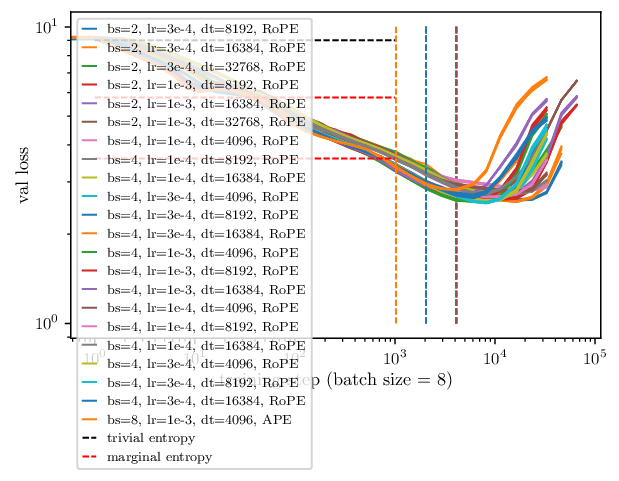

In [2]:
matplotlib.use("pgf")
matplotlib.rcParams.update({
    "pgf.texsystem": "pdflatex",
    'font.family': 'serif',
    'text.usetex': True,
    'pgf.rcfonts': False,
    'font.size': 10,
    'lines.markersize': 4,
    'lines.linewidth': 1.0,
})
# fig, ax = plt.subplots(1, 1, figsize=(1*3.8, 1*2.4), dpi=120)
fig, ax = plt.subplots(1, 1, figsize=(1*5.7, 1*3.6), dpi=120)
custom_lines = []
custom_labels = []


vocab_size = 8192
split = 'train'
i = -1

T = 128
P = 1048576
path = f'tinystories/trained/T{T}_rope/P{P}/'

depth = 12
de = 768
nh = 12

bs = 2
for lr in ['3e-4', '1e-3']:
    for dt in [8192, 16384, 32768]:
        dt_ep = dt//(P/(bs*T))
        i += 1
        prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
        collection = collect( path, prefix)
        mean_loss = []
        for entry in collection:

            results = torch.load(path+prefix+entry['ending'])
            dynamics = results['dynamics']
            ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
            mean_loss.append(results['best']['loss'])
        #     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
        print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
        ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
        custom_lines.append(Line2D([0], [0], color=f'C{i}'))
        custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}, RoPE')

        
bs = 4
for lr in ['1e-4', '3e-4','1e-3']:
    for dt in [4096, 8192, 16384]:
        dt_ep = dt//(P/(bs*T))
        i += 1
        prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
        collection = collect( path, prefix)
        mean_loss = []
        for entry in collection:

            results = torch.load(path+prefix+entry['ending'])
            dynamics = results['dynamics']
            ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
            mean_loss.append(results['best']['loss'])
        #     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
        print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
        ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
        custom_lines.append(Line2D([0], [0], color=f'C{i}'))
        custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}, RoPE')

depth = 12
de = 1024
nh = 16
bs = 4
for lr in ['1e-4', '3e-4']:
    for dt in [4096, 8192, 16384]:
        dt_ep = dt//(P/(bs*T))
        i += 1
        prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
        collection = collect( path, prefix)
        mean_loss = []
        for entry in collection:

            results = torch.load(path+prefix+entry['ending'])
            dynamics = results['dynamics']
            ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
            mean_loss.append(results['best']['loss'])
        #     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
        print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
        ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
        custom_lines.append(Line2D([0], [0], color=f'C{i}'))
        custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}, RoPE')
# bs = 8
# for lr in ['3e-4','1e-3']:
#     for dt in [2048, 4096, 8192]:
#         dt_ep = dt//(P/(bs*T))
#         i += 1
#         prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
#         collection = collect( path, prefix)
#         mean_loss = []
#         for entry in collection:

#             results = torch.load(path+prefix+entry['ending'])
#             dynamics = results['dynamics']
#             ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
#             mean_loss.append(results['best']['loss'])
#         #     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
#         print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
#         ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
#         custom_lines.append(Line2D([0], [0], color=f'C{i}'))
#         custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}, RoPE')


path = f'tinystories/trained/T{T}/P{P}/'

depth = 12
de = 768
nh = 12

bs = 8
lr = '1e-3'
dt = 4096
dt_ep = dt//(P/(bs*T))
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
mean_loss = []
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    mean_loss.append(results['best']['loss'])
#     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}, APE')


ax.plot([1e0,1e3],[math.log(8192),math.log(8192)], 'k--')
custom_lines.append(Line2D([0], [0], color='k', linestyle='dashed'))
custom_labels.append(fr'trivial entropy')

marginal = np.load("../SLM/datasets/tinystories/"+f"tinystories.BPE{vocab_size}.{split}_marginal.npy")
marginal = torch.from_numpy(marginal)
marg_ent = torch.masked_select(marginal, (marginal>0))
print(marg_ent.size())
marg_ent = -(marg_ent*marg_ent.log()).sum()
print(marg_ent)
ax.plot([1e0,1e3],[marg_ent.cpu(),marg_ent.cpu()], 'r--')
custom_lines.append(Line2D([0], [0], color='r', linestyle='dashed'))
custom_labels.append(fr'marginal entropy')


ax.plot([1e0,1e3],[3.60,3.60], 'r--')


ax.legend(custom_lines, custom_labels, fontsize=8, handlelength=1)
# ax.set_xlim(1,16)
ax.set_xscale('log')
# ax.set_ylim(1.,5.)
ax.set_yscale('log')

ax.set_ylabel(fr'val loss', fontsize=11)
ax.set_xlabel(fr'training step (batch size $={bs}$)', fontsize=11)

# $P=2^{22}$

768 2 1e-4 2.0 tensor(2.2170) tensor(0.0121)
768 2 1e-4 4.0 tensor(2.1503) tensor(0.0188)
768 2 1e-4 8.0 tensor(2.2093) tensor(0.0145)
768 2 3e-4 2.0 tensor(2.1028) tensor(0.0130)
768 2 3e-4 4.0 tensor(2.0988) tensor(0.0046)
768 2 3e-4 8.0 tensor(2.1828) tensor(0.0115)
768 2 1e-3 2.0 tensor(2.1469) tensor(0.0187)
768 2 1e-3 4.0 tensor(2.1731) tensor(0.0083)
768 2 1e-3 8.0 tensor(2.2227) tensor(0.0158)
768 4 1e-4 2.0 tensor(2.2617) tensor(0.0153)
768 4 1e-4 4.0 tensor(2.1801) tensor(0.0200)
768 4 1e-4 8.0 tensor(2.2216) tensor(0.0141)
768 4 3e-4 2.0 tensor(2.1066) tensor(0.0120)
768 4 3e-4 4.0 tensor(2.0832) tensor(0.0105)
768 4 3e-4 8.0 tensor(2.1753) tensor(0.0143)
768 4 1e-3 2.0 tensor(2.1286) tensor(0.0074)
768 4 1e-3 4.0 tensor(2.1606) tensor(0.0129)
768 4 1e-3 8.0 tensor(2.2039) tensor(0.0143)
1024 4 1e-4 2.0 tensor(2.2168) tensor(0.0053)
1024 4 1e-4 4.0 tensor(2.1319) tensor(0.0134)
1024 4 1e-4 8.0 tensor(2.1971) tensor(0.0083)
1024 4 3e-4 2.0 tensor(2.0808) tensor(0.0158)
1024 4

Text(0.5, 0, 'training step (batch size $=8$)')

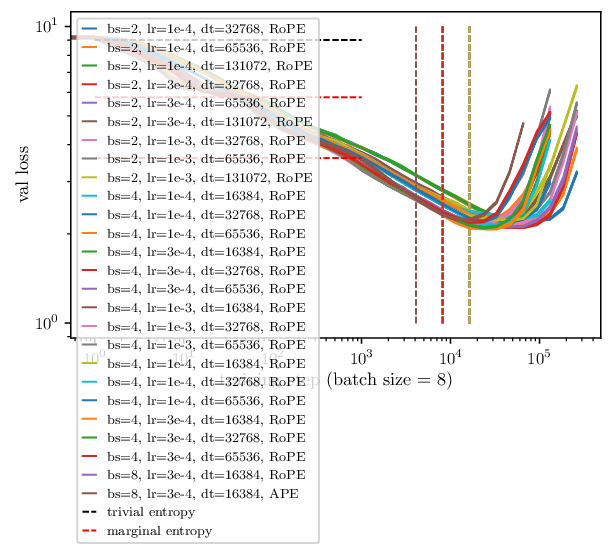

In [3]:
matplotlib.use("pgf")
matplotlib.rcParams.update({
    "pgf.texsystem": "pdflatex",
    'font.family': 'serif',
    'text.usetex': True,
    'pgf.rcfonts': False,
    'font.size': 10,
    'lines.markersize': 4,
    'lines.linewidth': 1.0,
})
# fig, ax = plt.subplots(1, 1, figsize=(1*3.8, 1*2.4), dpi=120)
fig, ax = plt.subplots(1, 1, figsize=(1*5.7, 1*3.6), dpi=120)
custom_lines = []
custom_labels = []


vocab_size = 8192
split = 'train'
i = -1

T = 128
P = 4194304
path = f'tinystories/trained/T{T}_rope/P{P}/'

depth = 12
de = 768
nh = 12

bs = 2
for lr in ['1e-4', '3e-4', '1e-3']:
    for dt in [32768, 65536, 131072]:
        dt_ep = dt//(P/(bs*T))
        i += 1
        prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
        collection = collect( path, prefix)
        mean_loss = []
        for entry in collection:

            results = torch.load(path+prefix+entry['ending'])
            dynamics = results['dynamics']
            ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
            mean_loss.append(results['best']['loss'])
        #     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
        print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
        ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
        custom_lines.append(Line2D([0], [0], color=f'C{i}'))
        custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}, RoPE')

        
bs = 4
for lr in [ '1e-4','3e-4','1e-3']:
    for dt in [ 16384, 32768, 65536]:
        dt_ep = dt//(P/(bs*T))
        i += 1
        prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
        collection = collect( path, prefix)
        mean_loss = []
        for entry in collection:

            results = torch.load(path+prefix+entry['ending'])
            dynamics = results['dynamics']
            ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
            mean_loss.append(results['best']['loss'])
        #     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
        print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
        ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
        custom_lines.append(Line2D([0], [0], color=f'C{i}'))
        custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}, RoPE')

de = 1024
nh = 16
bs = 4
for lr in [ '1e-4','3e-4']:
    for dt in [ 16384, 32768, 65536]:
        dt_ep = dt//(P/(bs*T))
        i += 1
        prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
        collection = collect( path, prefix)
        mean_loss = []
        for entry in collection:

            results = torch.load(path+prefix+entry['ending'])
            dynamics = results['dynamics']
            ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
            mean_loss.append(results['best']['loss'])
        #     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
        print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
        ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
        custom_lines.append(Line2D([0], [0], color=f'C{i}'))
        custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}, RoPE')

bs = 8
lr = '3e-4'
dt = 16384
dt_ep = dt//(P/(bs*T))
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
mean_loss = []
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    mean_loss.append(results['best']['loss'])
#     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}, RoPE')

path = f'tinystories/trained/T{T}/P{P}/'

depth = 12
de = 768
nh = 12

bs = 8
lr = '3e-4'
dt = 16384
dt_ep = dt//(P/(bs*T))
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
mean_loss = []
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    mean_loss.append(results['best']['loss'])
#     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}, APE')


ax.plot([1e0,1e3],[math.log(8192),math.log(8192)], 'k--')
custom_lines.append(Line2D([0], [0], color='k', linestyle='dashed'))
custom_labels.append(fr'trivial entropy')

marginal = np.load("../SLM/datasets/tinystories/"+f"tinystories.BPE{vocab_size}.{split}_marginal.npy")
marginal = torch.from_numpy(marginal)
marg_ent = torch.masked_select(marginal, (marginal>0))
print(marg_ent.size())
marg_ent = -(marg_ent*marg_ent.log()).sum()
print(marg_ent)
ax.plot([1e0,1e3],[marg_ent.cpu(),marg_ent.cpu()], 'r--')
custom_lines.append(Line2D([0], [0], color='r', linestyle='dashed'))
custom_labels.append(fr'marginal entropy')


ax.plot([1e0,1e3],[3.60,3.60], 'r--')


ax.legend(custom_lines, custom_labels, fontsize=8, handlelength=1)
# ax.set_xlim(1,16)
ax.set_xscale('log')
# ax.set_ylim(1.,5.)
ax.set_yscale('log')

ax.set_ylabel(fr'val loss', fontsize=11)
ax.set_xlabel(fr'training step (batch size $={bs}$)', fontsize=11)

# $P=2^{24}$

768 4 1e-4 2.0 tensor(1.8066) tensor(0.0043)
768 4 1e-4 4.0 tensor(1.7749) tensor(0.0095)
768 4 1e-4 8.0 tensor(1.8270) tensor(0.0129)
768 4 3e-4 2.0 tensor(1.7551) tensor(0.0066)
768 4 3e-4 4.0 tensor(1.7535) tensor(0.0110)
768 4 3e-4 8.0 tensor(1.8169) tensor(0.0072)
768 4 1e-3 2.0 tensor(1.8158) tensor(0.0115)
768 4 1e-3 4.0 tensor(1.8149) tensor(0.0132)
768 4 1e-3 8.0 tensor(1.8500) tensor(0.0050)
768 8 1e-4 2.0 tensor(1.8481) tensor(0.0103)
768 8 1e-4 4.0 tensor(1.7951) tensor(0.0130)
768 8 1e-4 8.0 tensor(1.8271) tensor(0.0079)
768 8 3e-4 2.0 tensor(1.7514) tensor(0.0140)
768 8 3e-4 4.0 tensor(1.7441) tensor(0.0099)
768 8 3e-4 8.0 tensor(1.8033) tensor(0.0130)
768 8 1e-3 2.0 tensor(1.7933) tensor(0.0104)
768 8 1e-3 4.0 tensor(1.8002) tensor(0.0116)
768 8 1e-3 8.0 tensor(nan) tensor(nan)
768 16 3e-4 4.0 tensor(1.7480) tensor(0.0131)
768 16 3e-4 8.0 tensor(1.8027) tensor(0.0111)
768 16 1e-3 4.0 tensor(1.7757) tensor(0.0062)
768 16 1e-3 8.0 tensor(1.8243) tensor(0.0184)
768 8 3e-4 4

Text(0.5, 0, 'training step (batch size $=8$)')

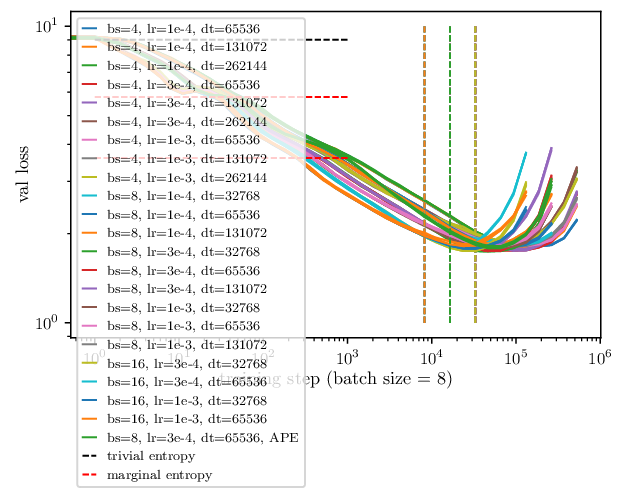

In [3]:
matplotlib.use("pgf")
matplotlib.rcParams.update({
    "pgf.texsystem": "pdflatex",
    'font.family': 'serif',
    'text.usetex': True,
    'pgf.rcfonts': False,
    'font.size': 10,
    'lines.markersize': 4,
    'lines.linewidth': 1.0,
})
# fig, ax = plt.subplots(1, 1, figsize=(1*3.8, 1*2.4), dpi=120)
fig, ax = plt.subplots(1, 1, figsize=(1*5.7, 1*3.6), dpi=120)
custom_lines = []
custom_labels = []


vocab_size = 8192
split = 'train'
i = -1

T = 128
P = 16777216
path = f'tinystories/trained/T{T}_rope/P{P}/'

depth = 12
de = 768
nh = 12

bs = 4
for lr in ['1e-4', '3e-4', '1e-3']:
    for dt in [ 65536, 131072, 262144]:
        dt_ep = dt//(P/(bs*T))
        i += 1
        prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
        collection = collect( path, prefix)
        mean_loss = []
        for entry in collection:

            results = torch.load(path+prefix+entry['ending'])
            dynamics = results['dynamics']
            ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
            mean_loss.append(results['best']['loss'])
        #     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
        print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
        ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
        custom_lines.append(Line2D([0], [0], color=f'C{i}'))
        custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')

bs = 8
for lr in ['1e-4','3e-4','1e-3']:
    for dt in [32768, 65536, 131072]:
        dt_ep = dt//(P/(bs*T))
        i += 1
        prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
        collection = collect( path, prefix)
        mean_loss = []
        for entry in collection:

            results = torch.load(path+prefix+entry['ending'])
            dynamics = results['dynamics']
            ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
            mean_loss.append(results['best']['loss'])
        #     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
        print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
        ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
        custom_lines.append(Line2D([0], [0], color=f'C{i}'))
        custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')

bs = 16
for lr in ['3e-4','1e-3']:
    for dt in [32768, 65536]:
        dt_ep = dt//(P/(bs*T))
        i += 1
        prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
        collection = collect( path, prefix)
        mean_loss = []
        for entry in collection:

            results = torch.load(path+prefix+entry['ending'])
            dynamics = results['dynamics']
            ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
            mean_loss.append(results['best']['loss'])
        #     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
        print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
        ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
        custom_lines.append(Line2D([0], [0], color=f'C{i}'))
        custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')

path = f'tinystories/trained/T{T}/P{P}/'

depth = 12
de = 768
nh = 12

bs = 8
lr = '3e-4'
dt = 65536
dt_ep = dt//(P/(bs*T))
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
mean_loss = []
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    mean_loss.append(results['best']['loss'])
#     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}, APE')


ax.plot([1e0,1e3],[math.log(8192),math.log(8192)], 'k--')
custom_lines.append(Line2D([0], [0], color='k', linestyle='dashed'))
custom_labels.append(fr'trivial entropy')

marginal = np.load("../SLM/datasets/tinystories/"+f"tinystories.BPE{vocab_size}.{split}_marginal.npy")
marginal = torch.from_numpy(marginal)
marg_ent = torch.masked_select(marginal, (marginal>0))
print(marg_ent.size())
marg_ent = -(marg_ent*marg_ent.log()).sum()
print(marg_ent)
ax.plot([1e0,1e3],[marg_ent.cpu(),marg_ent.cpu()], 'r--')
custom_lines.append(Line2D([0], [0], color='r', linestyle='dashed'))
custom_labels.append(fr'marginal entropy')


ax.plot([1e0,1e3],[3.60,3.60], 'r--')


ax.legend(custom_lines, custom_labels, fontsize=8, handlelength=1)
# ax.set_xlim(1,16)
ax.set_xscale('log')
# ax.set_ylim(1.,5.)
ax.set_yscale('log')

ax.set_ylabel(fr'val loss', fontsize=11)
ax.set_xlabel(fr'training step (batch size $={bs}$)', fontsize=11)